In [1]:
!nvidia-smi

Wed Jun 11 19:07:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.03                 Driver Version: 561.03         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   55C    P8              9W /   30W |     474MiB /   4096MiB |     42%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Biblioteki

In [52]:
import warnings

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from peft import LoraConfig, TaskType, get_peft_model
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    CLIPModel,
    CLIPProcessor,
    Trainer,
    TrainingArguments,
    pipeline,
)
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import confusion_matrix
from peft import prepare_model_for_kbit_training


warnings.filterwarnings("ignore")

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Dane

In [19]:
HATE_TRAIN = 'hate_train.csv'
PRED_DATA = 'hate_test_data.txt'

In [5]:
hate_train = pd.read_csv(HATE_TRAIN, delimiter=',')

hate_train.head()

,sentence,label
0,Dla mnie faworytem do tytułu będzie Cracovia. ...,0
1,@anonymized_account @anonymized_account Brawo ...,0
2,"@anonymized_account @anonymized_account Super,...",0
3,@anonymized_account @anonymized_account Musi. ...,0
4,"Odrzut natychmiastowy, kwaśna mina, mam problem",0


In [22]:
eval_set = pd.read_csv(PRED_DATA, delimiter='\t', header=None, names=['sentence'])

eval_set.head()

,sentence
0,"@anonymized_account Spoko, jak im Duda z Moraw..."
1,@anonymized_account @anonymized_account Ale on...
2,@anonymized_account No czy Prezes nie miał rac...
3,@anonymized_account @anonymized_account Przeci...
4,@anonymized_account @anonymized_account Owszem...


### Analiza Danych

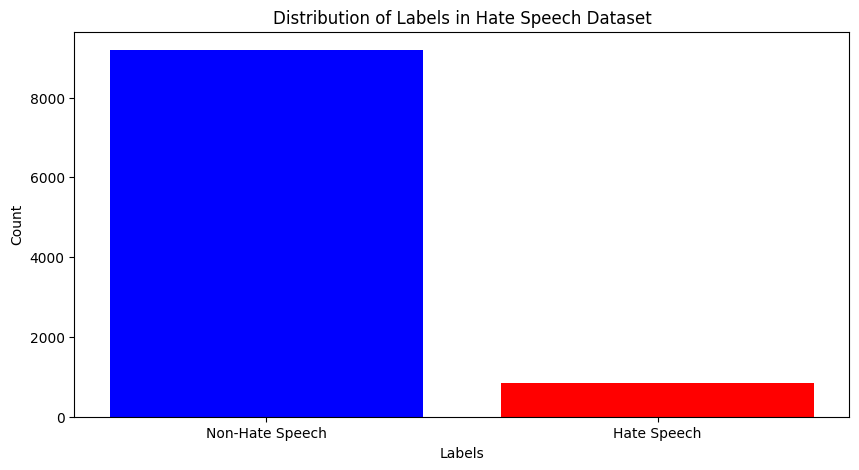

In [6]:
label_count = hate_train['label'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(label_count.index, label_count.values, color=['blue', 'red'])
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels in Hate Speech Dataset')
plt.xticks(ticks=label_count.index, labels=['Non-Hate Speech', 'Hate Speech'])
plt.show()

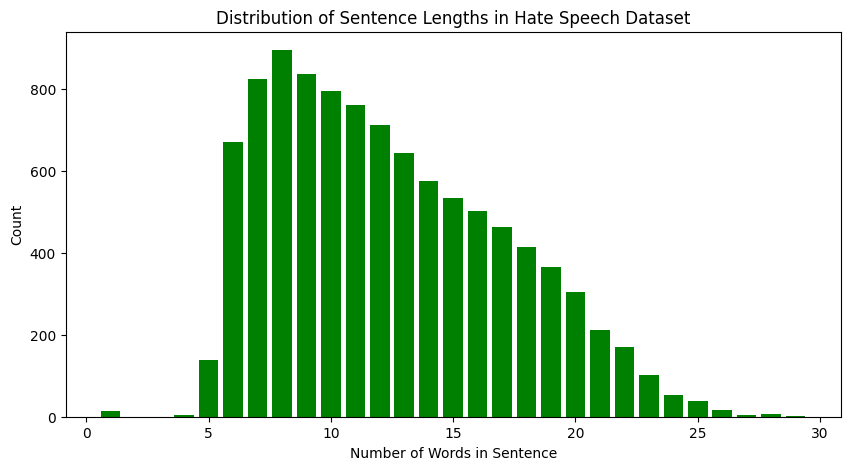

In [7]:
text_lengths = hate_train['sentence'].apply(lambda x: len(x.split())).value_counts()
text_lengths = text_lengths.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(text_lengths.index, text_lengths.values, color='green')
plt.xlabel('Number of Words in Sentence')
plt.ylabel('Count')
plt.title('Distribution of Sentence Lengths in Hate Speech Dataset')
plt.show()

In [8]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(hate_train['label']),
    y=hate_train['label']
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class weights:", class_weights)

Class weights: tensor([0.5463, 5.8995])


### HateSpeech Dataset

In [18]:
class HateSpeechDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.max_length = max_length

        if isinstance(data, pd.DataFrame):
            self.texts = data["sentence"].tolist()
            self.labels = data["label"].tolist() if "label" in data.columns else None

        elif isinstance(data, (list, pd.Series)):
            self.texts = list(data)
            self.labels = None
        else:
            self.texts = [data]
            self.labels = None

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }
        if self.labels is not None:
            label = self.labels[idx]
            item['labels'] = torch.tensor(label, dtype=torch.long)
        return item

### Funkcje pomocnicze

In [29]:
def compute_metrics(eval_preds):
    preds, labels = eval_preds

    probababilities = torch.nn.functional.softmax(torch.tensor(preds), dim=-1)
    positive_probs = probababilities[:, 1]
    predictions = torch.argmax(probababilities, dim=-1)

    accuracy_score_value = accuracy_score(labels, predictions)
    auc_score = roc_auc_score(labels, positive_probs)

    return {
        'accuracy': accuracy_score_value,
        'auc': auc_score
    }

def evaluate_and_plot(trainer, test_dataset):
    eval_results = trainer.evaluate()
    for name, value in eval_results.items():
        print(f"{name:25s}: {value:.4f}")
    print()

    y_true = [example['labels'].item() for example in test_dataset]

    preds_output = trainer.predict(test_dataset)
    y_pred = preds_output.predictions.argmax(axis=1)

    cm = confusion_matrix(y_true, y_pred)

    label_names = ['Non-Hate Speech', 'Hate Speech']

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return eval_results, cm

### Model

In [11]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, output_attentions=False, output_hidden_states=False
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
hate_dataset = HateSpeechDataset(
    dataframe=hate_train,
    tokenizer=AutoTokenizer.from_pretrained('distilbert-base-uncased'),
    max_length=128
)

In [13]:
train_df, test_df  = train_test_split(
    hate_train, test_size=0.2, random_state=42, stratify=hate_train['label'])

train_dataset = HateSpeechDataset(train_df, tokenizer)
test_dataset = HateSpeechDataset(test_df, tokenizer)

In [14]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


#### Ustawienie parametrów do trenowania

In [15]:
for name, param in model.base_model.named_parameters():
    param.requires_grad = False

for name, param in model.base_model.named_parameters():
    if 'pooler' in name:
        param.requires_grad = True


In [16]:
LR = 2e-4
BATCH_SIZE = 64
NUM_EPOCHS = 20

training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    logging_strategy='epoch',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)


In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Auc
1,0.302100,0.285582,0.915381,0.638362
2,0.285500,0.281456,0.915381,0.657502
3,0.279200,0.281399,0.915381,0.665736
4,0.278700,0.278492,0.915381,0.676944
5,0.274000,0.275360,0.915381,0.684099
6,0.274200,0.279514,0.915381,0.689508
7,0.271500,0.272060,0.915381,0.694604
8,0.270300,0.271033,0.915381,0.697729
9,0.269400,0.287626,0.915381,0.699578
10,0.270800,0.271944,0.915381,0.700732


TrainOutput(global_step=2520, training_loss=0.2711137907845633, metrics={'train_runtime': 1357.2214, 'train_samples_per_second': 118.359, 'train_steps_per_second': 1.857, 'total_flos': 5319890730024960.0, 'train_loss': 0.2711137907845633, 'epoch': 20.0})

#### Ewaluacja wyników

eval_loss                : 0.2856
eval_accuracy            : 0.9154
eval_auc                 : 0.6384
eval_runtime             : 13.0972
eval_samples_per_second  : 153.3920
eval_steps_per_second    : 2.4430
epoch                    : 20.0000



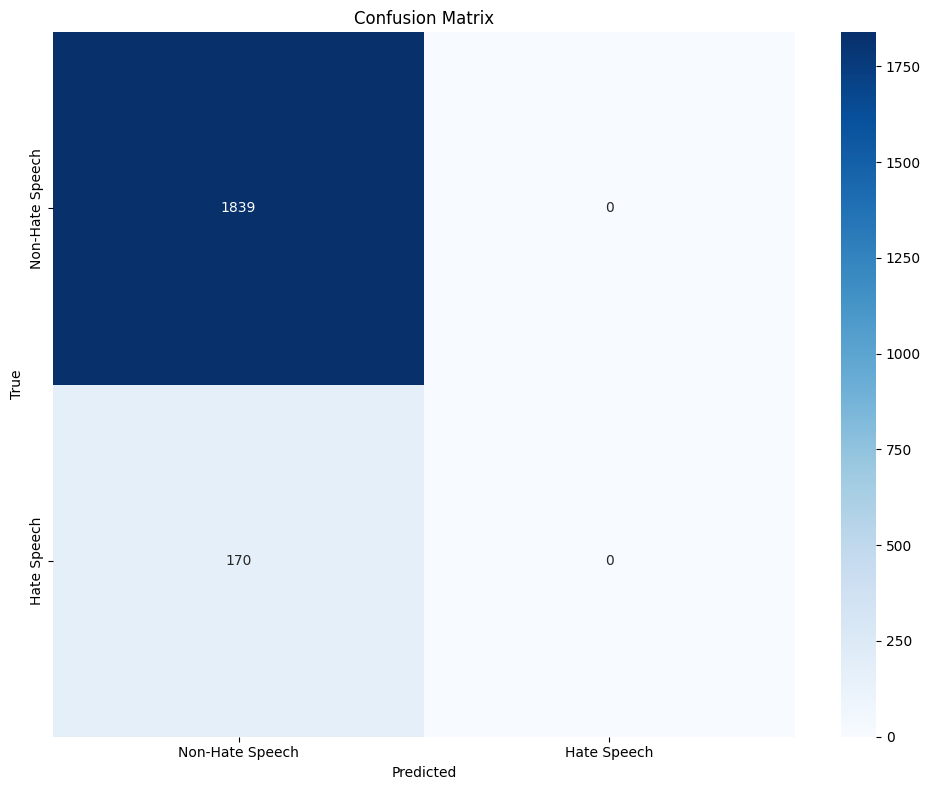

In [28]:
results, cm = evaluate_and_plot(trainer, test_dataset)

### Własny Trainer do uwzględniania wag klas

In [ ]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        device = logits.device

        weights = self.class_weights.to(device)


        loss_fct = nn.CrossEntropyLoss(weight=weights)

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss


In [37]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    logging_strategy='epoch',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    report_to="none"
)


trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)


trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Auc
1,0.675300,0.663117,0.491289,0.643956
2,0.660600,0.653529,0.618218,0.660257
3,0.643400,0.647249,0.554505,0.668960
4,0.642500,0.642248,0.576406,0.675808
5,0.631000,0.642773,0.694375,0.684000
6,0.632000,0.641666,0.694375,0.687839
7,0.624500,0.632564,0.605276,0.693996
8,0.623900,0.632238,0.605774,0.693535
9,0.618500,0.701456,0.874067,0.695416
10,0.621800,0.642891,0.738676,0.697428


TrainOutput(global_step=2520, training_loss=0.6210272501385401, metrics={'train_runtime': 1363.6669, 'train_samples_per_second': 117.8, 'train_steps_per_second': 1.848, 'total_flos': 5319890730024960.0, 'train_loss': 0.6210272501385401, 'epoch': 20.0})

eval_loss                : 0.7015
eval_accuracy            : 0.8741
eval_auc                 : 0.6954
eval_runtime             : 14.3159
eval_samples_per_second  : 140.3330
eval_steps_per_second    : 2.2350
epoch                    : 20.0000



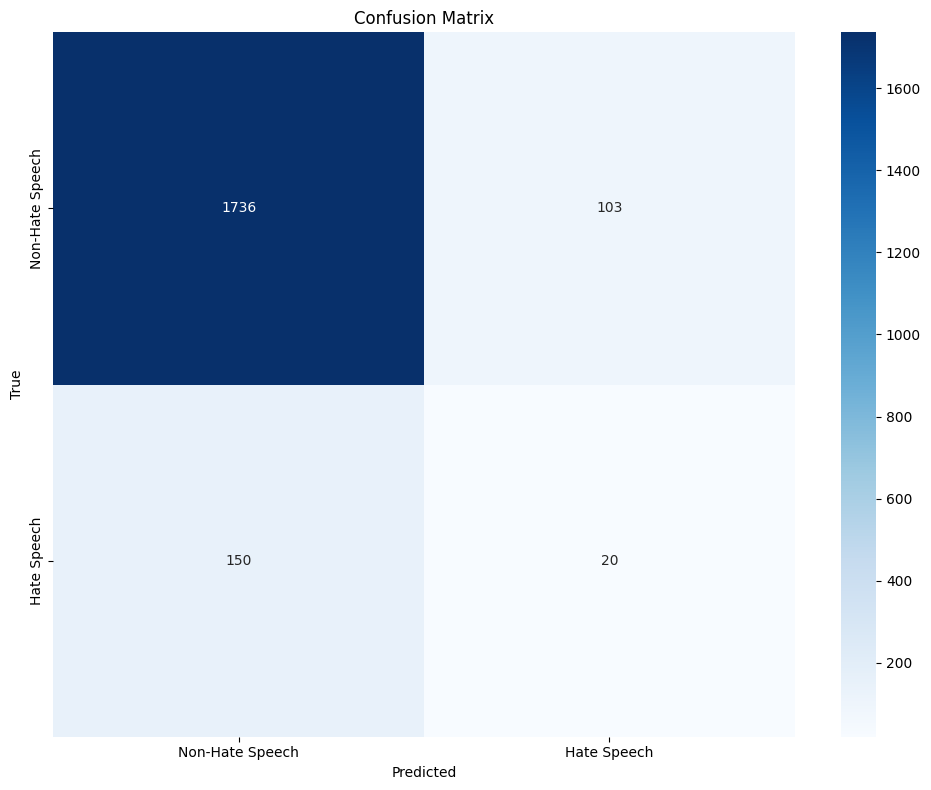

In [38]:
results, cm = evaluate_and_plot(trainer, test_dataset)

### LORA

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)

model.to(device)

model = prepare_model_for_kbit_training(model)

# 4. Skonfiguruj LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS",
)

model = get_peft_model(model, lora_config)


trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
all_params       = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,}  — "
      f"Total params: {all_params:,}  "
      f"({100*trainable_params/all_params:.2f}% trainable)")


training_args = TrainingArguments(
    output_dir='./lora_results',
    learning_rate=LR,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=NUM_EPOCHS,
    logging_strategy='epoch',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    report_to="none",
    fp16=True,
)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

trainer.train()


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Trainable params: 887,042  — Total params: 67,842,052  (1.31% trainable)


Epoch,Training Loss,Validation Loss,Accuracy,Auc
1,0.676200,0.631355,0.548034,0.691245
2,0.619500,0.618456,0.534594,0.736241
3,0.566800,0.573487,0.680438,0.788782
4,0.513600,0.594333,0.842210,0.804329
5,0.487000,0.563817,0.782977,0.808336
6,0.459000,0.635607,0.848183,0.811334
7,0.446300,0.559474,0.767546,0.817796
8,0.407300,0.593271,0.793927,0.820801
9,0.374600,0.824591,0.880538,0.809937
10,0.360800,0.689046,0.838726,0.813996


TrainOutput(global_step=5020, training_loss=0.38509591623131495, metrics={'train_runtime': 1068.043, 'train_samples_per_second': 150.406, 'train_steps_per_second': 4.7, 'total_flos': 5429326449868800.0, 'train_loss': 0.38509591623131495, 'epoch': 20.0})

eval_loss                : 1.3795
eval_accuracy            : 0.8990
eval_auc                 : 0.7804
eval_runtime             : 6.2773
eval_samples_per_second  : 320.0440
eval_steps_per_second    : 10.0360
epoch                    : 20.0000



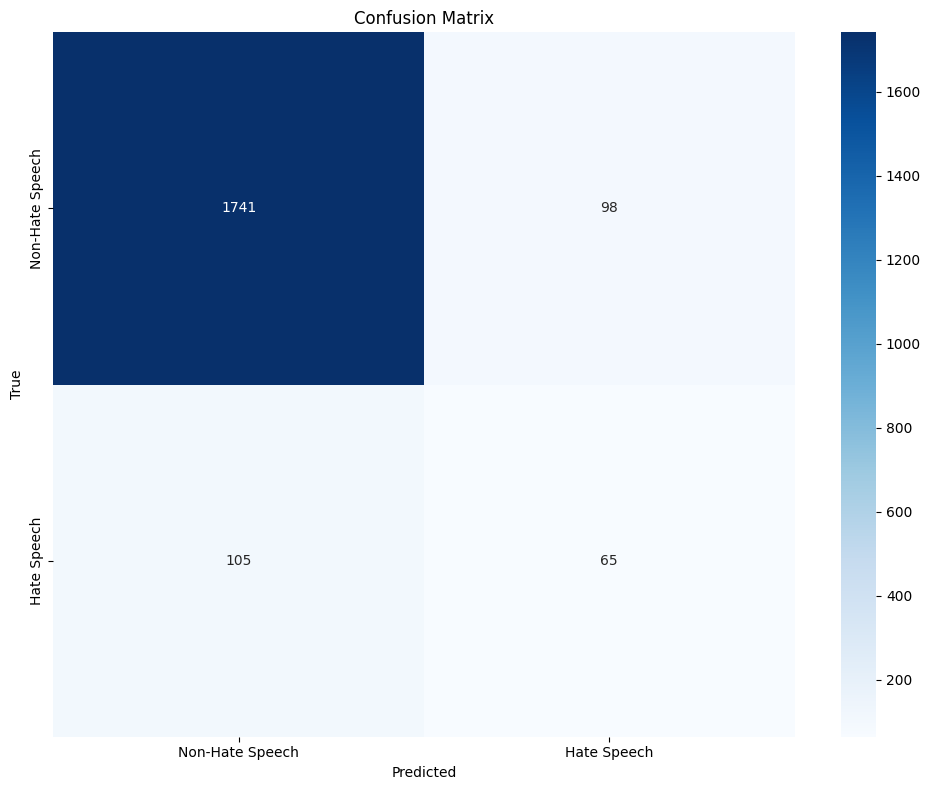

In [42]:
results, cm = evaluate_and_plot(trainer, test_dataset)

### OverSampling

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights=class_weights,
    num_samples=len(class_weights),
    replacement=True
)

train_dataloader =